In [76]:
# cleanup and fix isogeometric plate case
# first let's plot the basis functions from _plate.py
import numpy as np

# 1) make the open knot vector
nxe, p = 4, 2
# nxe, p = 4, 1
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
print(f"{knots=}")
n_ctrl = nxe + p # number of control ponts

# 2) find span to determine where in vector to do interpolations
def find_span(n_ctrl, degree, u, U):
    # Cox-de Boor span search (n_ctrl = number of control points)
    if u >= U[-1] - 1e-12:
        return n_ctrl - 1
    low = degree
    high = len(U)-degree-1
    mid = (low+high)//2
    while True:
        if u < U[mid]:
            high = mid
        elif u >= U[mid+1]:
            low = mid
        else:
            return mid
        mid = (low+high)//2

# get basis functions

def basis_functions_and_derivatives(span, u, degree, U, n_deriv=1):
    # Compute nonzero basis functions and first derivatives using Cox-de Boor + derivative formula
    # Returns arrays N[0:degree] and dN[0:degree]
    left = np.zeros(degree+1)
    right = np.zeros(degree+1)
    ndu = np.zeros((degree+1, degree+1))
    ndu[0,0] = 1.0
    for j in range(1, degree+1):
        left[j] = u - U[span+1-j]
        right[j] = U[span+j] - u
        saved = 0.0
        for r in range(j):
            ndu[j,r] = right[r+1] + left[j-r]
            temp = ndu[r,j-1]/ndu[j,r]
            ndu[r,j] = saved + right[r+1]*temp
            saved = left[j-r]*temp
        ndu[j,j] = saved
    N = ndu[:,degree].copy()
    # derivatives
    ders = np.zeros((n_deriv+1, degree+1))
    a = np.zeros((2, degree+1))
    # compute a triangular table of derivatives
    for r in range(degree+1):
        s1 = 0; s2 = 1
        a[0,0] = 1.0
        for k in range(1, n_deriv+1):
            d = 0.0
            rk = r - k
            pk = degree - k
            if r >= k:
                a[s2,0] = a[s1,0]/ndu[pk+1,rk]
                d = a[s2,0]*ndu[rk,pk]
            j1 = 1 if rk >= -1 else -rk
            j2 = k-1 if r-1 <= pk else degree - r
            for j in range(j1, j2+1):
                a[s2,j] = (a[s1,j] - a[s1,j-1]) / ndu[pk+1, rk+j]
                d += a[s2,j]*ndu[rk+j, pk]
            if r <= pk:
                a[s2,k] = -a[s1,k-1]/ndu[pk+1, r]
                d += a[s2,k]*ndu[r, pk]
            ders[k,r] = d
            s1, s2 = s2, s1
    # Multiply by correct factors
    for k in range(1, n_deriv+1):
        for j in range(degree+1):
            ders[k,j] *= degree
    return N, ders[1]

knots=[0.0, 0.0, 0.0, 0.25, 0.5, 0.75, 1.0, 1.0, 1.0]


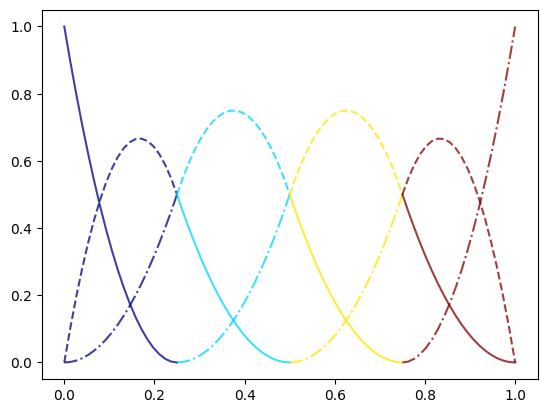

In [77]:
# now plot each separate basis function in the span?
import matplotlib.pyplot as plt

ielem = 0
colors = plt.cm.jet(np.linspace(0.0, 1.0, nxe))
linestyles = ['-', '--', '-.']

for i in range(len(knots)-1):
    knot1 = knots[i]; knot2 = knots[i+1]
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        uvec = np.linspace(knot1, knot2, 20)
        span = find_span(n_ctrl, p, np.mean(uvec), knots)  # gets starting index?
        Nvals = np.zeros((p+1, uvec.shape[0]))
        for ii, _u in enumerate(uvec):
            N, deriv = basis_functions_and_derivatives(span, _u, p, knots, n_deriv=1)
            Nvals[:,ii] = N[:]

        for iN in range(p+1):
            rand_scale = 0.0
            # rand_scale = 0.05
            plt.plot(uvec, Nvals[iN,:] + np.random.rand(1)*rand_scale, linestyle=linestyles[iN], color=colors[ielem], alpha=0.75)
        
        ielem += 1
plt.show()


uhat_vec=array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])
uhat_vec=array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])
uhat_vec=array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])
uhat_vec=array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57

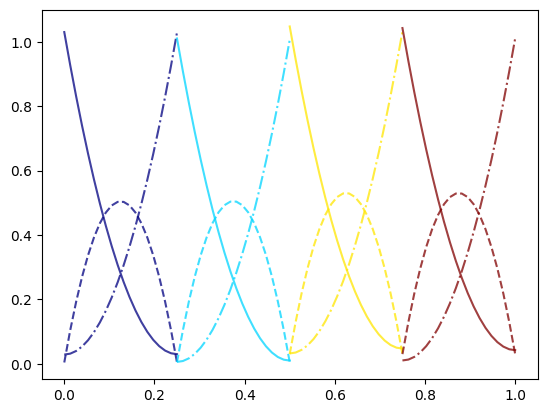

In [78]:
# now compare with the basis functions from the _plate_v2.py function (which might be slightly messed up near boundary?)

def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN


ielem = 0
colors = plt.cm.jet(np.linspace(0.0, 1.0, nxe))
linestyles = ['-', '--', '-.']

for i in range(len(knots)-1):
    knot1 = knots[i]; knot2 = knots[i+1]
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        uvec = np.linspace(knot1, knot2, 20)
        uhat_vec = (uvec - knot1) / dknot
        print(f"{uhat_vec=}")
        Nvals = np.zeros((p+1, uvec.shape[0]))
        for ii, _uhat in enumerate(uhat_vec):
            N, deriv = quad_bernstein(_uhat)
            Nvals[:, ii] = N[:]

        for iN in range(p+1):
            plt.plot(uvec, Nvals[iN,:] + np.random.rand(1)*0.05, linestyle=linestyles[iN], color=colors[ielem], alpha=0.75)
        
        ielem += 1
plt.show()

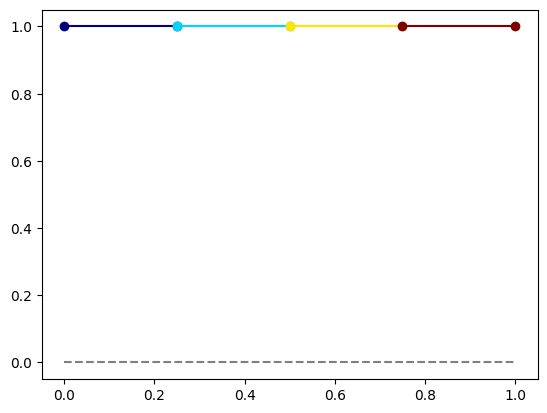

In [79]:
# this wasn't quite right so I'm gonna build up the basis functions step by step..
# there are 4 zeroth order, 5 1st order and 6 2nd order basis functions

# 1) the zeroth order basis functions 
ielem = 0
for i in range(len(knots)-1):
    knot1 = knots[i]; knot2 = knots[i+1]
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        # some random shifting so we can see them better
        plt.plot([knot1, knot2], [1.0 + np.random.rand(1)*0.0]*2, 'o-', color=colors[ielem])
        ielem += 1
plt.plot([0.0, 1.0], [0.0]*2, color="tab:gray", linestyle='--')
plt.show()

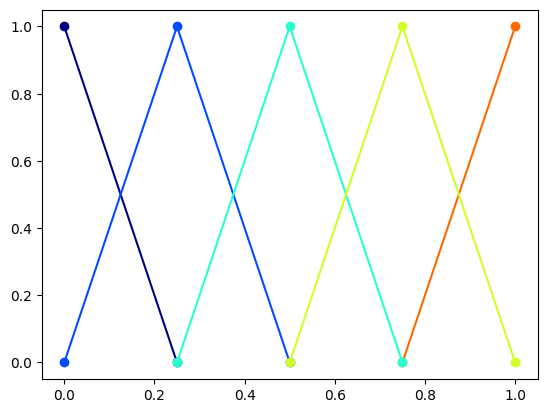

In [80]:
# 2) now the first order basis functions (five of them)
colors = plt.cm.jet(np.linspace(0.0, 1.0, 6))

# two half-basis functions on exterior
plt.plot([0.0, 0.25], [1.0, 0.0], 'o-', color=colors[0])
plt.plot([0.75, 1.0], [0.0, 1.0], 'o-',color=colors[4])

# now we have three groups of two elements for the basis functions on the interior
for i in range(3):
    plt.plot([0.25*i, 0.25*(i+1), 0.25*(i+2)], [0.0, 1.0, 0.0], 'o-', color=colors[i+1])

plt.show()

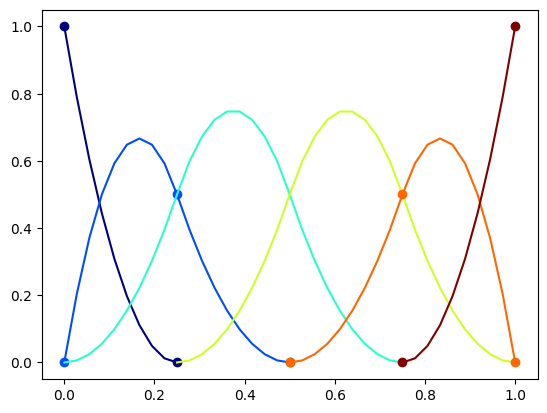

In [81]:
# now for 2nd order, we have (done by hand V1):

# 1) N_{0,2}(u) = (0.25 - u) / 0.25 * N_{1,1}(u) = (1-4u) * (1-4u) = (1-4u)^2
# with support only on [0, 0, 0, 0.25] or just [0, 0.25]
# this becomes N_{0,2}(u) = 1 - 8u + 16u^2 
#    = (1-xi)^2 in xi = 4u coords
xi = np.linspace(0.0, 1.0, 10)
plt.plot(0.25*xi, (1.0 - xi)**2, '-', color=colors[0])
plt.plot([0.0, 0.25], [1.0, 0.0], 'o', color=colors[0])

# 2) N_{1,2}(u) with support [0, 0, 0.25, 0.5] = u/0.25 * N_{1,1}(u) + (0.5 - u) / 0.5 * N_{2,1}(u)
# becomes on [0, 0.25] : 4u*(1-4u) + (1-2u) * 4u = 8u - 24 u^2 = 2*xi - 1.5 * xi^2
# becomes on [0.25, 0.5] : (1-2u)*(0.5-u)/0.25 = (1-2u)*(2-4u) = 2*(1-2u)^2 = 0.5 * (1-xi)^2
plt.plot(0.25 * xi, 2*xi - 1.5 * xi**2, color=colors[1])
plt.plot(0.25*(1+xi), 0.5 * (1 - xi)**2, color=colors[1])
plt.plot([0.0, 0.25, 0.5], [0.0, 0.5, 0.0], 'o', color=colors[1])

# 3) N_{2,2}(u) with support [0, 0.25, 0.5, 0.75] support so combines 3 elements?
# = u/0.5 * N_{2,1}(u) + (0.75-u) / 0.5 * N_{3,1}(u)
# becomes on [0, 0.25] : 2u * 4u = 8u^2 = 0.5 * xi^2  (so that the sum first three basis functions on [0, 0.25] is 1)
# becomes on [0.25, 0.5] : 2u * (2-4u) + (1.5-2u) * (4u-1) = 0.5*(1+xi) * (1-xi) + 0.5*(2-xi) * xi = 0.5 + xi - xi^2
# becomes on [0.5, 0.75] : (1.5-2u) * (4u-2) = 0.5*(1-xi) * (1-xi) = 0.5*(1-xi)^2
plt.plot(0.25*xi, 0.5 * xi**2, color=colors[2])
plt.plot(0.25*(1+xi), 0.5 + xi - xi**2, color=colors[2])
plt.plot(0.5 + 0.25*xi, 0.5*(1-xi)**2, color=colors[2])

# 4) similar thing for N_{3,2} with support [0.25, 0.5, 0.75, 1] but flipped
plt.plot(0.25+0.25*xi, 0.5 * xi**2, color=colors[3])
plt.plot(0.5 + 0.25*xi, 0.5 + xi - xi**2, color=colors[3])
plt.plot(0.75 + 0.25*xi, 0.5*(1-xi)**2, color=colors[3])

# 5) now N_{4,2} is same thing as N_{1,2} but flipped..
plt.plot(0.5 + 0.25*xi, 0.5 * xi**2, color=colors[4])
plt.plot(0.75 + 0.25*xi, 2*(1-xi) - 1.5 * (1-xi)**2, color=colors[4])
plt.plot([0.5, 0.75, 1.0], [0.0, 0.5, 0.0], 'o', color=colors[4])

# 6) and now N_{5,2} is like N_{0,2} but flipped
plt.plot(0.75 + 0.25*xi, xi**2, color=colors[5])
plt.plot([0.75, 1.0], [0.0, 1.0], 'o', color=colors[5])


plt.show()

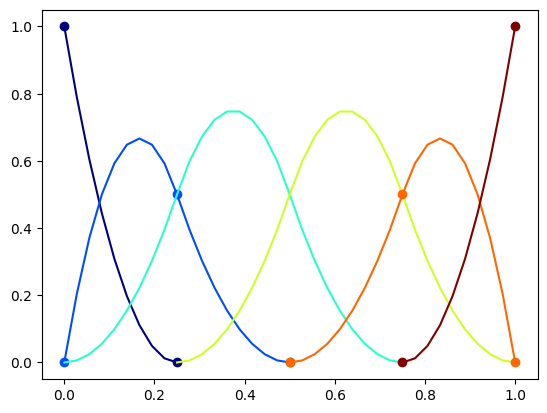

In [84]:
# now for 2nd order, we have (done by hand V2) using linear combinations of quadratic bernstein polynomials
# in each case I gave the ref or true polynomials from previous section
# and then as l.c. of the quadratic bernstein polynomials for each case..

def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN
# get quadratic bernstein polynomials
xi = np.linspace(0.0, 1.0, 10)
B, dB = quad_bernstein(xi)


# 1) N_{0,2}(u) with support [0, 0, 0, 0.25] ---------------------
# REF:
# plt.plot(0.25*xi, (1.0 - xi)**2, '-', color=colors[0])
plt.plot(0.25*xi, B[0], '-', color=colors[0])
plt.plot([0.0, 0.25], [1.0, 0.0], 'o', color=colors[0])

# solve for part N_{1,2}(u) next the Bernstein coefficients
# a * (1-xi)^2 + b * (2xi - 2xi^2) + c * xi^2 = 2 * xi - 1.5 * xi^2
# a = 0, b = 1.0, c = 0.5

# 2) N_{1,2}(u) with support [0, 0, 0.25, 0.5] ---------------------
# plt.plot(0.25 * xi, 2*xi - 1.5 * xi**2, color=colors[1])
# plt.plot(0.25*(1+xi), 0.5 * (1 - xi)**2, color=colors[1])
plt.plot(0.25 * xi, B[1] + 0.5 * B[2], color=colors[1])
plt.plot(0.25*(1+xi), 0.5 * B[0], color=colors[1])
plt.plot([0.0, 0.25, 0.5], [0.0, 0.5, 0.0], 'o', color=colors[1])

# similarly with the middle part of N_{2,2}(u) or third basis function being
# 0.5 + xi - xi^2, we can find it as a l.c. of the bernstein polynomials as:
# a=c probably by sym means a * (1-2*xi+2*xi^2) + b * (2 * xi - 2 * xi^2)
# a = 0.5 and b = 1.0 works! so really a=b/2=c=0.5 from full bernstein

# 3) N_{2,2}(u) with support [0, 0.25, 0.5, 0.75] ---------------------
# plt.plot(0.25*xi, 0.5 * xi**2, color=colors[2])
# plt.plot(0.25*(1+xi), 0.5 + xi - xi**2, color=colors[2])
# plt.plot(0.5 + 0.25*xi, 0.5*(1-xi)**2, color=colors[2])
plt.plot(0.25*xi, 0.5 * B[2], color=colors[2])
plt.plot(0.25*(1+xi), 0.5 * (B[0] + 2*B[1] + B[2]), color=colors[2])
plt.plot(0.5 + 0.25*xi, 0.5*B[0], color=colors[2])

# 4) N_{3,2}(u) with support [0.25, 0.5, 0.75, 1] ---------------------
# plt.plot(0.25+0.25*xi, 0.5 * xi**2, color=colors[3])
# plt.plot(0.5 + 0.25*xi, 0.5 + xi - xi**2, color=colors[3])
# plt.plot(0.75 + 0.25*xi, 0.5*(1-xi)**2, color=colors[3])
plt.plot(0.25+0.25*xi, 0.5 * B[2], color=colors[3])
plt.plot(0.5 + 0.25*xi, 0.5 * (B[0] + 2*B[1] + B[2]), color=colors[3])
plt.plot(0.75 + 0.25*xi, 0.5 * B[0], color=colors[3])

# 5) N_{4,2}(u) with support [0.5, 0.75, 1, 1] ---------------------
# plt.plot(0.5 + 0.25*xi, 0.5 * xi**2, color=colors[4])
# plt.plot(0.75 + 0.25*xi, 2*(1-xi) - 1.5 * (1-xi)**2, color=colors[4])
plt.plot(0.5 + 0.25*xi, 0.5 * B[2], color=colors[4])
plt.plot(0.75 + 0.25*xi, 0.5 * (B[0] + 2*B[1]), color=colors[4])

plt.plot([0.5, 0.75, 1.0], [0.0, 0.5, 0.0], 'o', color=colors[4])

# 6) N_{5,2}(u) with support [0.75, 1, 1, 1] ---------------------
# plt.plot(0.75 + 0.25*xi, xi**2, color=colors[5])
plt.plot(0.75 + 0.25*xi, B[2], color=colors[5])

plt.plot([0.75, 1.0], [0.0, 1.0], 'o', color=colors[5])

plt.show()

ndegen_knots=[0.0, 0.25, 0.5, 0.75, 1.0]


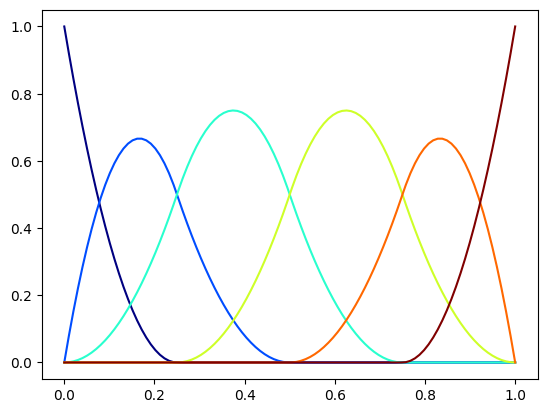

In [ ]:
# general pattern then goes something like this adding from each element to global basis functions

def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN

u = np.linspace(0.0, 1.0, 100)
nglob = nxe + p
global_basis = np.zeros((nglob, u.shape[0]))

# local basis to global basis connectivities?
elem_conn = [
    [i, i+1, i+2] for i in range(nxe) # element connectivity
]

# for order 2 get the list of nonzero knot pairs (pre-computed)
ndegen_knots = knots[2:-2] # all knots whose pairs are nz diff, nondegen
print(f"{ndegen_knots=}")
for ielem in range(len(ndegen_knots)-1):
# for ielem in range(1):
    knot1, knot2 = ndegen_knots[ielem], ndegen_knots[ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    # define optional BtoN coeffs based on element position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if ielem == 0 else 0.5
    N2_B0 = 1.0 if ielem == 0 else 0.5
    N1_B2 = 0.0 if ielem == (len(ndegen_knots)-2) else 0.5
    N0_B2 = 1.0 if ielem == (len(ndegen_knots)-2) else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask

# now plot each global basis function
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])
plt.show()

ndegen_knots=[0.0, 0.25, 0.5, 0.75, 1.0]


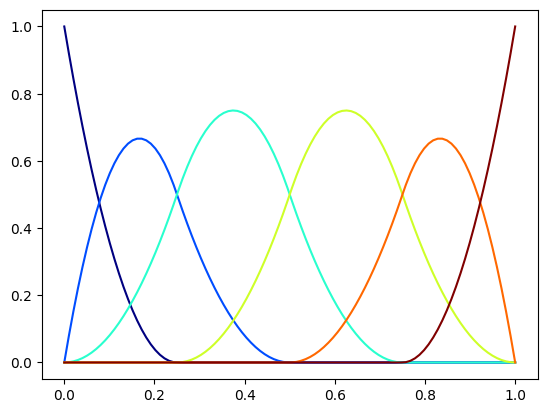

In [103]:
# or an even more robust way that just reads the knots to the left and right.. to check whether it's a boundary..

def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN

u = np.linspace(0.0, 1.0, 100)
nglob = nxe + p
global_basis = np.zeros((nglob, u.shape[0]))

# local basis to global basis connectivities?
elem_conn = [
    [i, i+1, i+2] for i in range(nxe) # element connectivity
]

# for order 2 get the list of nonzero knot pairs (pre-computed)
print(f"{ndegen_knots=}")
for ielem in range(nxe):
# for ielem in range(1):
    knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    left_bndry = abs(knots[p+ielem-1] - knot1) < 1e-12
    right_bndry = abs(knots[p+ielem+2] - knot2) < 1e-12

    # define optional BtoN coeffs based on element position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if left_bndry else 0.5
    N2_B0 = 1.0 if left_bndry else 0.5
    N1_B2 = 0.0 if right_bndry else 0.5
    N0_B2 = 1.0 if right_bndry else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask

# now plot each global basis function
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])
plt.show()

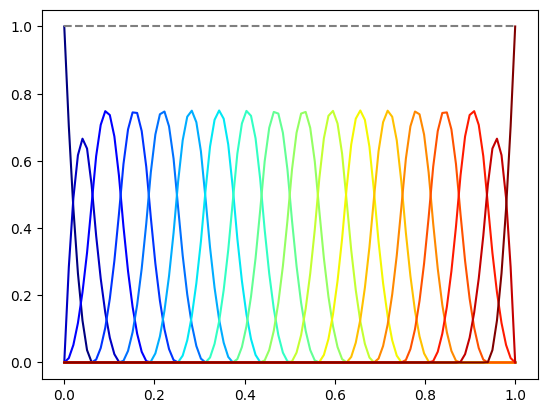

In [ ]:
# now let's run it again with higher number of elements!
import matplotlib.pyplot as plt
import numpy as np

nxe, p = 16, 2
nglob = nxe+p # number of global basis functions
colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN
u = np.linspace(0.0, 1.0, 100)
global_basis = np.zeros((nglob, u.shape[0]))
elem_conn = [
    [i, i+1, i+2] for i in range(nxe) # element connectivity
]
for ielem in range(nxe):
# for ielem in range(1):
    knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    left_bndry = abs(knots[p+ielem-1] - knot1) < 1e-12
    right_bndry = abs(knots[p+ielem+2] - knot2) < 1e-12

    # define optional BtoN coeffs based on el;ement position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if left_bndry else 0.5
    N2_B0 = 1.0 if left_bndry else 0.5
    N1_B2 = 0.0 if right_bndry else 0.5
    N0_B2 = 1.0 if right_bndry else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask

# now plot each global basis function
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])

# and check the sum of each basis functions
SUM = np.sum(global_basis, axis=0)
plt.plot(u, SUM, '--', color="tab:gray")
# sum is 1!
plt.show()